# Store Sales – Time Series Forecasting: EDA & Action Plan

**Competition:** [Kaggle – Store Sales Time Series Forecasting](https://www.kaggle.com/competitions/store-sales-time-series-forecasting). The task is to predict daily unit `sales` for every (store, product family) pair of the Ecuadorian grocery chain Corporación Favorita, for the 16 days **2017-08-16 → 2017-08-31**.

**Files:**

| file | content |
|---|---|
| `train.csv` | daily sales per (date, store, family) + `onpromotion` |
| `test.csv` | same grid for the 16-day forecast horizon (no `sales`) |
| `stores.csv` | store metadata: city, state, type, cluster |
| `oil.csv` | daily WTI oil price (Ecuador is an oil-dependent economy) |
| `holidays_events.csv` | national/regional/local holidays and events |
| `transactions.csv` | daily transaction counts per store |

This notebook stays strictly in the **exploration & planning** phase: no models are built. It ends with a preprocessing plan and a modelling strategy grounded in the findings.

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA = Path('../data')

In [2]:
train = pd.read_csv(DATA / 'train.csv', parse_dates=['date'])
test = pd.read_csv(DATA / 'test.csv', parse_dates=['date'])
stores = pd.read_csv(DATA / 'stores.csv')
oil = pd.read_csv(DATA / 'oil.csv', parse_dates=['date'])
holidays = pd.read_csv(DATA / 'holidays_events.csv', parse_dates=['date'])
transactions = pd.read_csv(DATA / 'transactions.csv', parse_dates=['date'])

tables = {'train': train, 'test': test, 'stores': stores,
          'oil': oil, 'holidays': holidays, 'transactions': transactions}

overview = pd.DataFrame({
    'rows': {k: len(v) for k, v in tables.items()},
    'cols': {k: v.shape[1] for k, v in tables.items()},
    'memory_mb': {k: round(v.memory_usage(deep=True).sum() / 1e6, 1) for k, v in tables.items()},
    'date_min': {k: v['date'].min().date() if 'date' in v else None for k, v in tables.items()},
    'date_max': {k: v['date'].max().date() if 'date' in v else None for k, v in tables.items()},
})
overview

,rows,cols,memory_mb,date_min,date_max
train,3000888,6,299.40,2013-01-01,2017-08-15
test,28512,5,2.60,2017-08-16,2017-08-31
stores,54,5,0.00,None,None
oil,1218,2,0.00,2013-01-01,2017-08-31
holidays,350,6,0.10,2012-03-02,2017-12-26
transactions,83488,3,2.00,2013-01-01,2017-08-15


**Takeaway:** `train` is the only large table (~3.0 M rows, ~140 MB) spanning **2013-01-01 → 2017-08-15**; `test` covers the next 16 days. `transactions` stops exactly at the end of train (no test coverage), while `oil` and `holidays` extend past the test window and can be used as future-known covariates.

In [3]:
train.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.00,0
1,1,2013-01-01,1,BABY CARE,0.00,0
2,2,2013-01-01,1,BEAUTY,0.00,0
3,3,2013-01-01,1,BEVERAGES,0.00,0
4,4,2013-01-01,1,BOOKS,0.00,0


In [4]:
train.dtypes.to_frame('dtype').join(train.nunique().to_frame('nunique'))

,dtype,nunique
id,int64,3000888
date,datetime64[us],1684
store_nbr,int64,54
family,str,33
sales,float64,379610
onpromotion,int64,362


In [5]:
# Panel structure: is train a complete (date x store x family) grid?
n_dates = train['date'].nunique()
n_stores = train['store_nbr'].nunique()
n_families = train['family'].nunique()
print(f'{n_dates} dates x {n_stores} stores x {n_families} families = {n_dates * n_stores * n_families:,}')
print(f'train rows = {len(train):,}  -> complete grid: {len(train) == n_dates * n_stores * n_families}')

full_range = pd.date_range(train['date'].min(), train['date'].max(), freq='D')
missing_dates = full_range.difference(train['date'].unique())
print('calendar dates absent from train:', [str(d.date()) for d in missing_dates])

1684 dates x 54 stores x 33 families = 3,000,888
train rows = 3,000,888  -> complete grid: True
calendar dates absent from train: ['2013-12-25', '2014-12-25', '2015-12-25', '2016-12-25']


**Takeaway:** `train` is a *complete* panel — every one of the 1,684 dates contains all 54 × 33 = 1,782 (store, family) rows — except that **4 calendar dates are entirely absent: Dec 25 of 2013–2016** (stores closed). There are no gaps to re-index away; zeros are recorded explicitly.

## 2. Target Variable Analysis

The target is `sales`: unit sales of a product family in a store on a day (can be fractional, e.g. kilograms).

In [6]:
s = train['sales']
stats = pd.Series({
    'min': s.min(), 'median': s.median(), 'mean': s.mean(),
    'p90': s.quantile(0.9), 'p99': s.quantile(0.99), 'max': s.max(),
    'pct_zero': (s == 0).mean() * 100,
    'pct_fractional': (s % 1 != 0).mean() * 100,
    'skew_raw': s.skew(), 'skew_log1p': np.log1p(s).skew(),
})
stats.to_frame('sales')

,sales
min,0.00
median,11.00
mean,357.78
p90,867.00
p99,"5,507.00"
max,"124,717.00"
pct_zero,31.30
pct_fractional,15.40
skew_raw,7.36
skew_log1p,0.41


**Takeaway:** the target is extremely right-skewed (skew **7.4**; median 11 vs max 124,717) and **31.3 % of all rows are exact zeros**; `log1p(sales)` brings skew down to **0.41**, which is the standard justification for modelling on a log scale and evaluating with RMSLE. About 15 % of values are fractional (weight-based products), so `sales` is continuous, not a count.

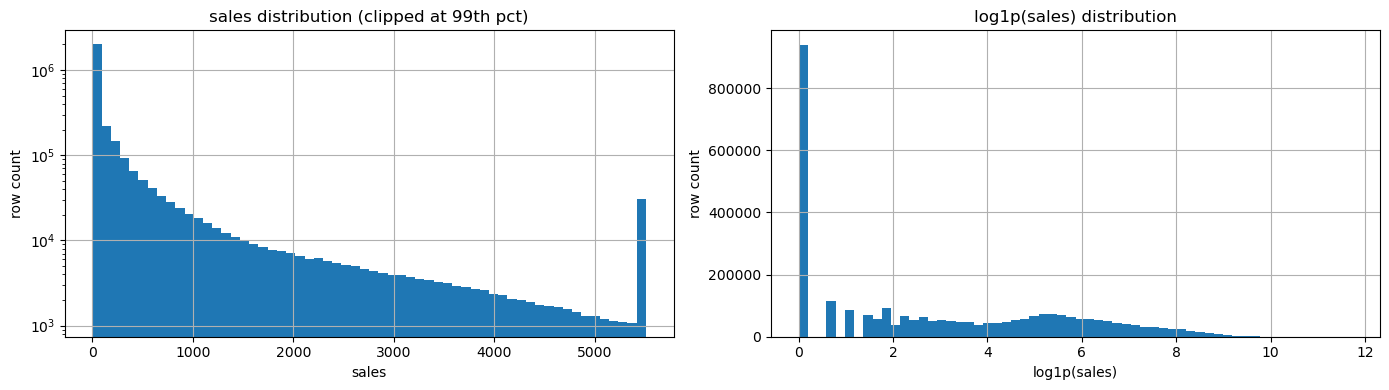

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(s.clip(upper=s.quantile(0.99)), bins=60)
axes[0].set_title('sales distribution (clipped at 99th pct)')
axes[0].set_xlabel('sales')
axes[0].set_ylabel('row count')
axes[0].set_yscale('log')

axes[1].hist(np.log1p(s), bins=60)
axes[1].set_title('log1p(sales) distribution')
axes[1].set_xlabel('log1p(sales)')
axes[1].set_ylabel('row count')

plt.tight_layout()
plt.show()

**Takeaway:** the raw scale is dominated by the spike at zero and a long thin tail, while `log1p` produces a well-behaved bimodal shape (the zero spike plus a roughly normal bulk) — a log-scale target with explicit handling of zeros is clearly the right working representation.

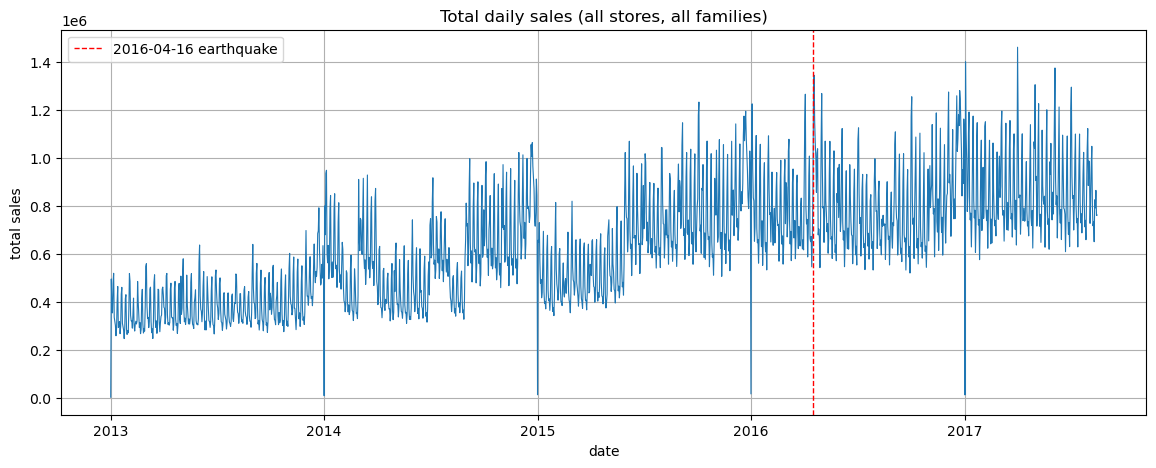

In [8]:
daily = train.groupby('date')[['sales', 'onpromotion']].sum()

fig, ax = plt.subplots()
ax.plot(daily.index, daily['sales'], linewidth=0.8)
ax.axvline(pd.Timestamp('2016-04-16'), color='red', linestyle='--', linewidth=1, label='2016-04-16 earthquake')
ax.set_title('Total daily sales (all stores, all families)')
ax.set_xlabel('date')
ax.set_ylabel('total sales')
ax.legend()
plt.show()

**Takeaway:** total sales show a steady upward trend, collapse to near zero every Jan 1, spike before Christmas, oscillate at a weekly frequency, and jump after the 2016-04-16 Ecuador earthquake (mean daily sales **+17.9 %** in the month after vs the month before) — trend, weekly/yearly seasonality and event effects all need to be captured.

## 3. Feature Overview

Features live in five tables that join onto the (date, store, family) grid:

- **Numerical:** `onpromotion` (train/test), `dcoilwtico` (oil), `transactions` — plus the target `sales`.
- **Categorical:** `family` (33), `store_nbr` (54), `city`, `state`, `type`, `cluster` (stores), and `type`, `locale`, `locale_name`, `description`, `transferred` (holidays). `cluster` is an integer label but nominal, not ordinal.
- **Datetime:** `date` everywhere — the source of calendar features.

In [9]:
rows = []
for tname, df in tables.items():
    for col in df.columns:
        if col in ('id', 'sales', 'date'):
            continue
        rows.append({'table': tname, 'column': col, 'dtype': str(df[col].dtype),
                     'nunique': df[col].nunique(),
                     'kind': 'numerical' if pd.api.types.is_numeric_dtype(df[col]) and col not in
                             ('store_nbr', 'cluster') else 'categorical'})
pd.DataFrame(rows).drop_duplicates(subset=['column', 'table']).sort_values(['kind', 'nunique'])

,table,column,dtype,nunique,kind
13,holidays,locale,str,3,categorical
9,stores,type,str,5,categorical
12,holidays,type,str,6,categorical
8,stores,state,str,16,categorical
10,stores,cluster,int64,17,categorical
7,stores,city,str,22,categorical
14,holidays,locale_name,str,24,categorical
1,train,family,str,33,categorical
4,test,family,str,33,categorical
0,train,store_nbr,int64,54,categorical


In [10]:
pd.concat([
    train['onpromotion'].describe().rename('onpromotion (train)'),
    test['onpromotion'].describe().rename('onpromotion (test)'),
    oil['dcoilwtico'].describe().rename('dcoilwtico'),
    transactions['transactions'].describe().rename('transactions'),
], axis=1)

,onpromotion (train),onpromotion (test),dcoilwtico,transactions
count,"3,000,888.00","28,512.00","1,175.00","83,488.00"
mean,2.60,6.97,67.71,"1,694.60"
std,12.22,20.68,25.63,963.29
min,0.00,0.00,26.19,5.00
25%,0.00,0.00,46.41,"1,046.00"
50%,0.00,0.00,53.19,"1,393.00"
75%,0.00,6.00,95.66,"2,079.00"
max,741.00,646.00,110.62,"8,359.00"


**Takeaway:** all categoricals are low-cardinality (≤ 54 levels except holiday `description`), so encoding is cheap. `onpromotion` is zero in **79.6 %** of train rows but only **55.9 %** of test rows — promotions ramp up over time (first non-zero value: 2014-04-01) and are *more* prevalent in the forecast window, so the model must use them despite their late start. Oil ranged 26–111 USD, and `transactions` is a store-day activity measure (mean ≈ 1,700/day).

## 4. Missing Values

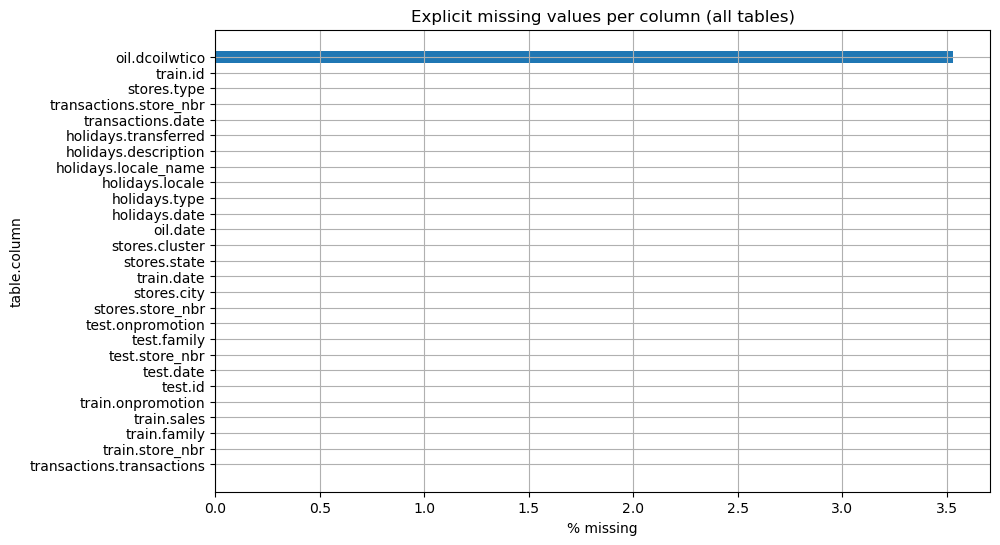

,pct_missing
table.column,
oil.dcoilwtico,3.53


In [11]:
miss = []
for tname, df in tables.items():
    pct = df.isna().mean() * 100
    for col, p in pct.items():
        miss.append({'table.column': f'{tname}.{col}', 'pct_missing': p})
miss = pd.DataFrame(miss).set_index('table.column').sort_values('pct_missing', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(miss.index, miss['pct_missing'])
ax.set_title('Explicit missing values per column (all tables)')
ax.set_xlabel('% missing')
ax.set_ylabel('table.column')
ax.invert_yaxis()
plt.show()

miss[miss['pct_missing'] > 0]

**Takeaway:** explicit NaNs exist in exactly one column — `oil.dcoilwtico` (**43 rows, 3.5 %**); every other column in every table is fully populated.

weekday counts in oil.csv (0=Mon): {0: 243, 1: 244, 2: 244, 3: 244, 4: 243}


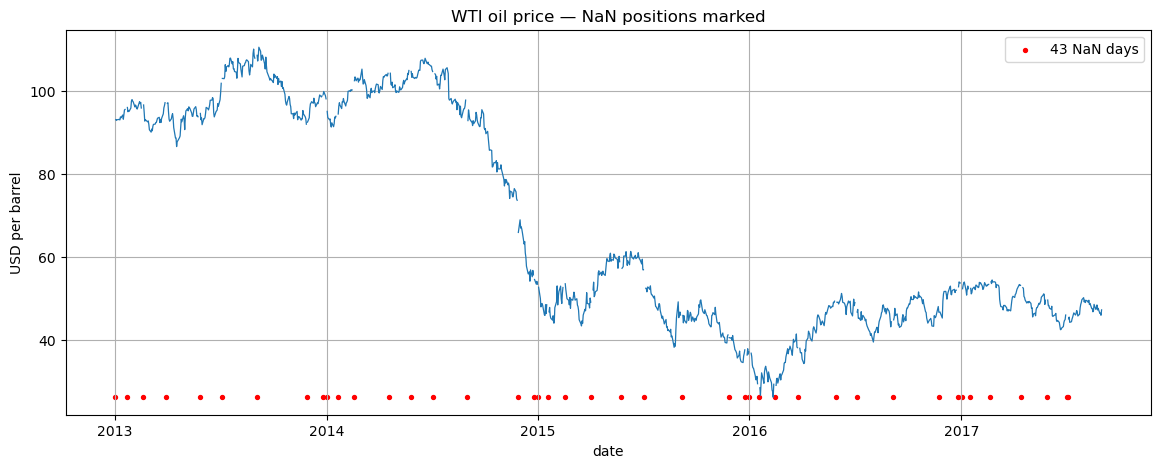

In [12]:
oil_idx = oil.set_index('date')['dcoilwtico']
print('weekday counts in oil.csv (0=Mon):', oil['date'].dt.dayofweek.value_counts().sort_index().to_dict())

fig, ax = plt.subplots()
ax.plot(oil_idx.index, oil_idx.values, linewidth=0.9)
nan_days = oil_idx.index[oil_idx.isna()]
ax.scatter(nan_days, [oil_idx.min()] * len(nan_days), color='red', s=8, label=f'{len(nan_days)} NaN days')
ax.set_title('WTI oil price — NaN positions marked')
ax.set_xlabel('date')
ax.set_ylabel('USD per barrel')
ax.legend()
plt.show()

**Takeaway:** the oil file contains **weekdays only** (zero Saturday/Sunday rows) and the in-file NaNs sit on US market holidays — this missingness is **structural / deterministic (calendar-driven), not random (not MCAR)**: markets are simply closed. The correct treatment is reindexing to the full calendar + forward-fill, not imputation by statistics.

stores with first recorded sale long after 2013-01-01:
store_nbr
53   2014-05-29
20   2015-02-13
29   2015-03-20
21   2015-07-24
42   2015-08-21
22   2015-10-09
52   2017-04-20


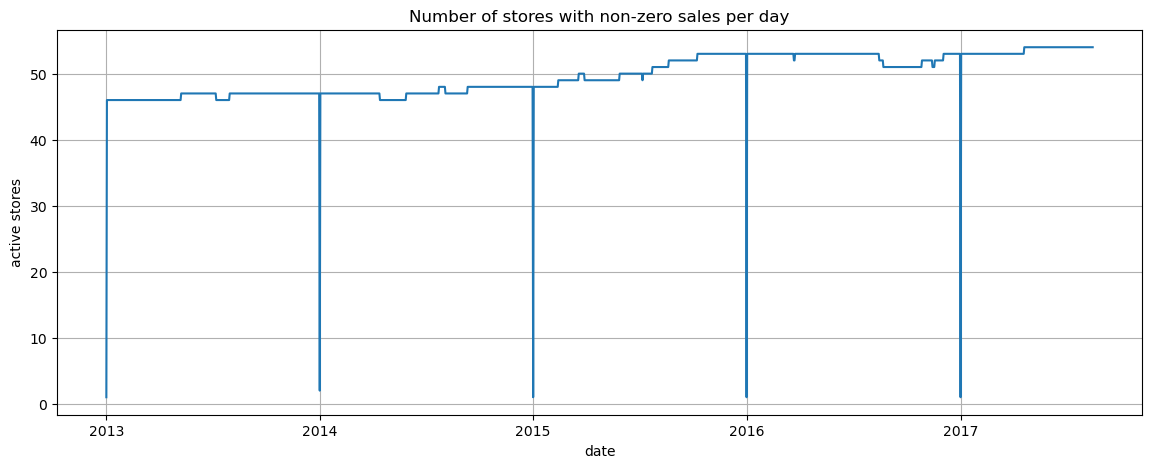

In [13]:
# Implicit missingness: stores that open mid-period (long runs of leading zeros)
first_sale = train[train['sales'] > 0].groupby('store_nbr')['date'].min()
late = first_sale[first_sale > '2013-06-01'].sort_values()
print('stores with first recorded sale long after 2013-01-01:')
print(late.to_string())

active = train[train['sales'] > 0].groupby('date')['store_nbr'].nunique()
fig, ax = plt.subplots()
ax.plot(active.index, active.values)
ax.set_title('Number of stores with non-zero sales per day')
ax.set_xlabel('date')
ax.set_ylabel('active stores')
plt.show()

**Takeaway:** besides explicit NaNs there is *implicit* missingness: **7 stores (53, 20, 29, 21, 42, 22, 52) open mid-period** — their leading zeros mean "store did not exist", not "zero demand" (store 52 only opens 2017-04-20). Together with the 4 absent Dec-25 dates and `transactions` covering **0 %** of test dates, all missingness here is **structural/explainable (MNAR by design)** rather than random.

## 5. Distributions & Outliers

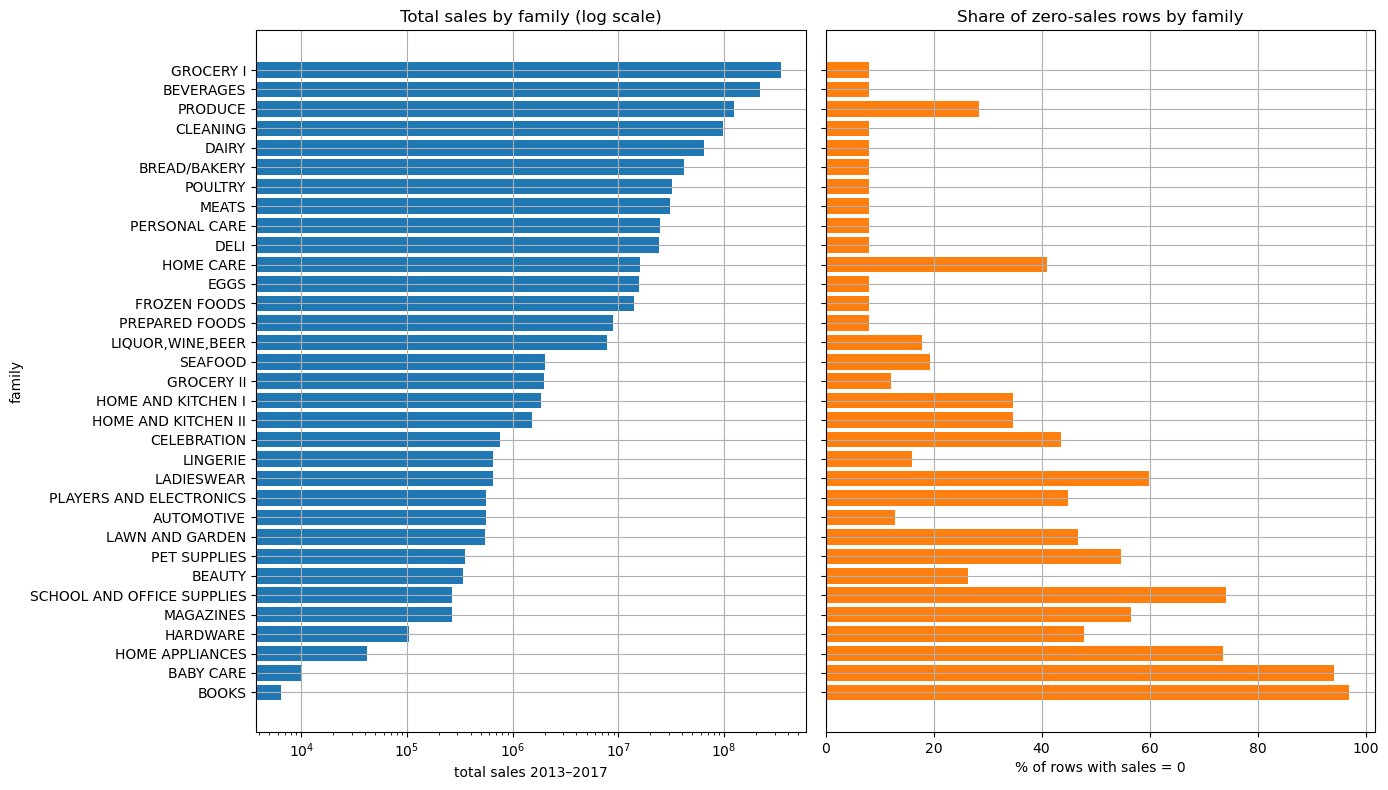

In [14]:
fam = train.groupby('family')['sales'].agg(total='sum', pct_zero=lambda x: (x == 0).mean() * 100)
fam = fam.sort_values('total')

fig, axes = plt.subplots(1, 2, figsize=(14, 8), sharey=True)
axes[0].barh(fam.index, fam['total'])
axes[0].set_xscale('log')
axes[0].set_title('Total sales by family (log scale)')
axes[0].set_xlabel('total sales 2013–2017')
axes[0].set_ylabel('family')

axes[1].barh(fam.index, fam['pct_zero'], color='tab:orange')
axes[1].set_title('Share of zero-sales rows by family')
axes[1].set_xlabel('% of rows with sales = 0')

plt.tight_layout()
plt.show()

**Takeaway:** family totals span ~5 orders of magnitude — GROCERY I (343 M) and BEVERAGES (217 M) dominate, while BOOKS sells 6.4 K in total and is zero in **97 %** of its rows (BABY CARE 94 %, SCHOOL & OFFICE 74 %) — several families are intermittent-demand series that behave completely differently from the high-volume ones.

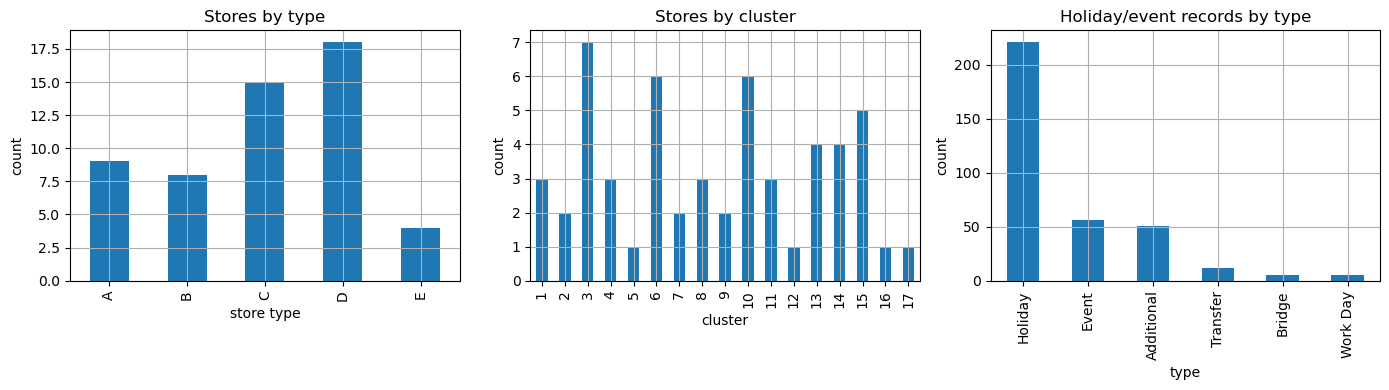

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

stores['type'].value_counts().sort_index().plot.bar(ax=axes[0])
axes[0].set_title('Stores by type')
axes[0].set_xlabel('store type')
axes[0].set_ylabel('count')

stores['cluster'].value_counts().sort_index().plot.bar(ax=axes[1])
axes[1].set_title('Stores by cluster')
axes[1].set_xlabel('cluster')
axes[1].set_ylabel('count')

holidays['type'].value_counts().plot.bar(ax=axes[2])
axes[2].set_title('Holiday/event records by type')
axes[2].set_xlabel('type')
axes[2].set_ylabel('count')

plt.tight_layout()
plt.show()

**Takeaway:** the 54 stores split into 5 types (D and C most common) and 17 clusters of 1–7 stores; the holiday table mixes six record types — 221 Holidays plus Events, Additional days, Transfers (12 holidays moved dates), Bridges and even 5 "Work Day" records (compensating workdays that *cancel* a day off) — so it needs careful parsing, not a naive join. 38 dates carry more than one holiday record, so joining requires de-duplication.

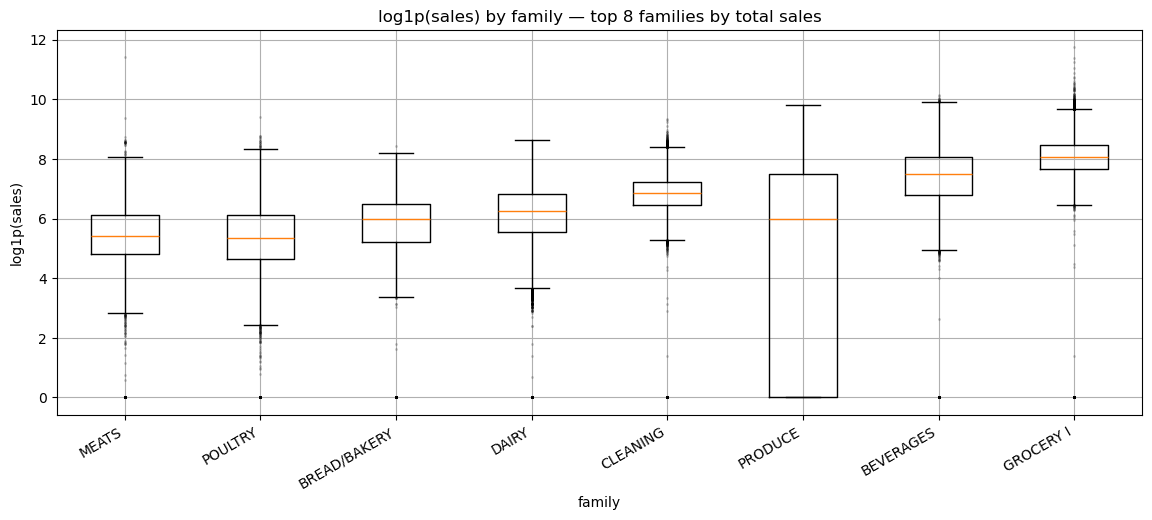

In [16]:
top8 = fam.sort_values('total').index[-8:]
data = [np.log1p(train.loc[train['family'] == f, 'sales']) for f in top8]

fig, ax = plt.subplots(figsize=(14, 5))
ax.boxplot(data, tick_labels=top8, showfliers=True, flierprops={'markersize': 1, 'alpha': 0.2})
ax.set_title('log1p(sales) by family — top 8 families by total sales')
ax.set_xlabel('family')
ax.set_ylabel('log1p(sales)')
plt.xticks(rotation=30, ha='right')
plt.show()

**Takeaway:** even on a log scale and within the top families, levels differ by several log-units and every family carries a fringe of extreme highs — scale is family- (and store-) specific, which argues for per-series features (lags, rolling stats) or per-series normalisation rather than one global scale.

In [17]:
# Outlier days: deviation from a 91-day rolling level
ds = daily['sales']
z = (ds - ds.rolling(91, center=True, min_periods=30).mean()) / ds.rolling(91, center=True, min_periods=30).std()
outliers = pd.concat([z.sort_values(ascending=False).head(5), z.sort_values().head(4)])
outliers.to_frame('rolling z-score').join(ds.to_frame('total sales'))

,rolling z-score,total sales
date,,
2017-04-01,3.57,"1,463,083.96"
2013-09-01,3.27,"640,406.22"
2013-06-02,3.09,"637,698.49"
2014-07-06,3.06,"918,276.60"
2015-03-01,3.04,"820,434.98"
2017-01-01,-4.13,"12,082.50"
2016-01-01,-4.12,"16,433.39"
2013-01-01,-3.69,"2,511.62"
2014-01-01,-3.34,"8,602.07"


**Takeaway:** every extreme day is *explainable*: the lows are all Jan 1 (stores closed), the highs are first-days-of-month / paydays and 2016-04-18 right after the earthquake — these are genuine demand signals, not data errors, so they should be **kept and encoded as features** (calendar flags, event flags), not removed or winsorised.

## 6. Correlations & Relationships

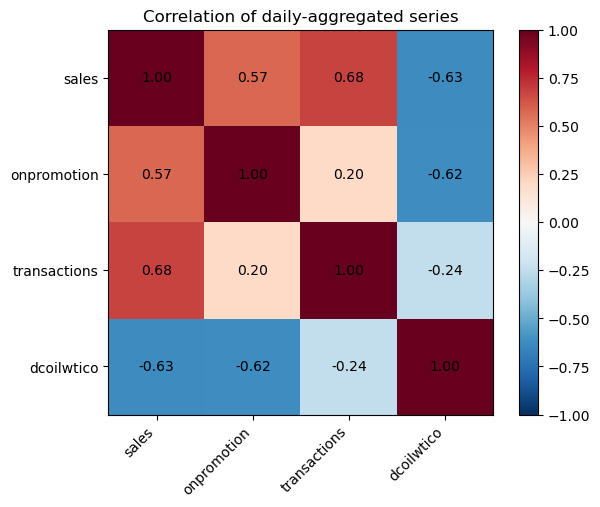

In [18]:
dtrans = transactions.groupby('date')['transactions'].sum()
doil = oil.set_index('date')['dcoilwtico'].reindex(daily.index).ffill()
m = daily.join(dtrans).join(doil)

corr = m.corr()
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center')
fig.colorbar(im)
ax.set_title('Correlation of daily-aggregated series')
ax.grid(False)
plt.show()

**Takeaway:** at daily level, sales correlate with transactions (**r = 0.68**), with promotions (**r = 0.58**, dropping to 0.43 within the promo era) and *negatively* with oil (**r = −0.63**) — but oil and promotions also correlate at −0.62 with each other purely because one trends down while the other trends up, a multicollinearity red flag checked next.

correlation in LEVELS  (daily):          -0.627
correlation in CHANGES (weekly pct chg): 0.037


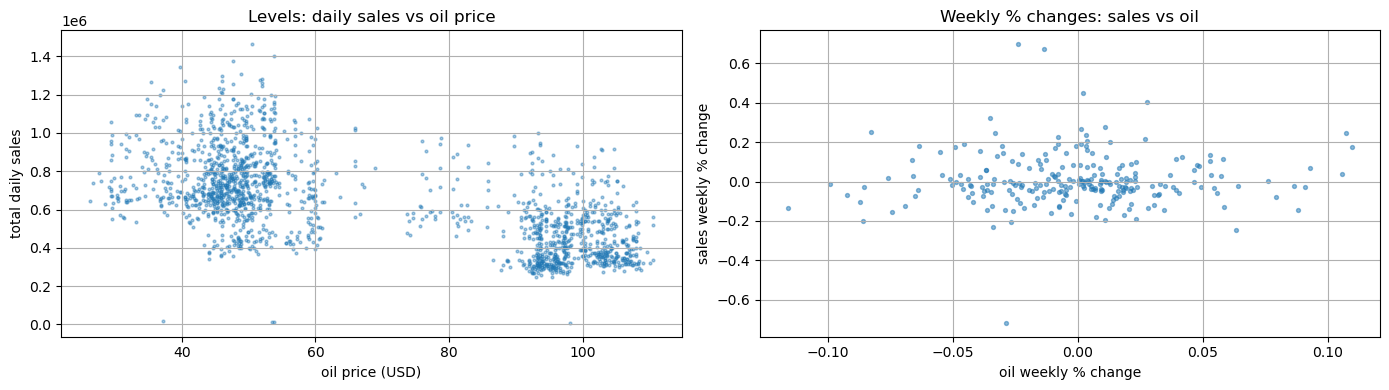

In [19]:
ws = daily['sales'].resample('W').sum().pct_change()
wo = doil.resample('W').mean().pct_change()
print(f'correlation in LEVELS  (daily):          {m["sales"].corr(m["dcoilwtico"]):.3f}')
print(f'correlation in CHANGES (weekly pct chg): {ws.corr(wo):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(m['dcoilwtico'], m['sales'], s=4, alpha=0.4)
axes[0].set_title('Levels: daily sales vs oil price')
axes[0].set_xlabel('oil price (USD)')
axes[0].set_ylabel('total daily sales')

axes[1].scatter(wo, ws, s=8, alpha=0.5)
axes[1].set_title('Weekly % changes: sales vs oil')
axes[1].set_xlabel('oil weekly % change')
axes[1].set_ylabel('sales weekly % change')

plt.tight_layout()
plt.show()

**Takeaway:** the strong negative oil–sales correlation (−0.63) **vanishes to 0.04 once both series are detrended** (weekly % changes) — it is a spurious co-trend, not a causal short-term driver; oil belongs in the model at most as a slow macro covariate, and linear models must not be fed oil + trend + promotions together untreated.

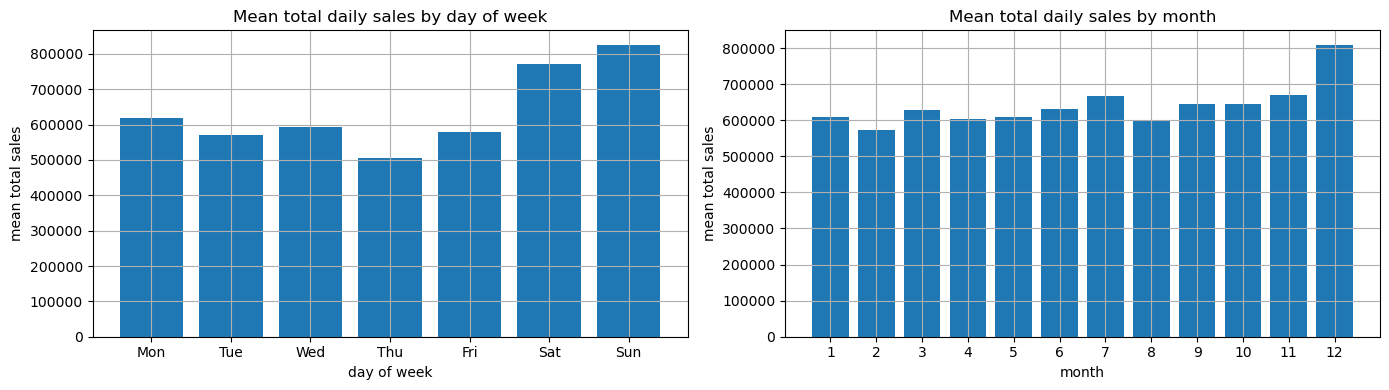

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

dow = daily['sales'].groupby(daily.index.dayofweek).mean()
axes[0].bar(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'], dow.values)
axes[0].set_title('Mean total daily sales by day of week')
axes[0].set_xlabel('day of week')
axes[0].set_ylabel('mean total sales')

mon = daily['sales'].groupby(daily.index.month).mean()
axes[1].bar(mon.index, mon.values)
axes[1].set_xticks(range(1, 13))
axes[1].set_title('Mean total daily sales by month')
axes[1].set_xlabel('month')
axes[1].set_ylabel('mean total sales')

plt.tight_layout()
plt.show()

**Takeaway:** weekends are the peak (Sun ≈ 825 K, Sat ≈ 772 K vs Thu ≈ 505 K — a **+63 %** Sunday-over-Thursday gap) and December stands ~27 % above an average month — day-of-week is the single strongest calendar effect, with a clear yearly cycle on top.

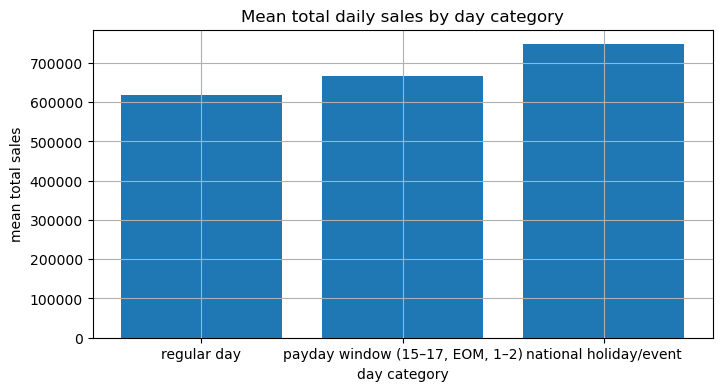

,mean daily sales
regular day,"618,834.74"
"payday window (15–17, EOM, 1–2)","665,704.94"
national holiday/event,"747,262.61"


In [21]:
nat = holidays[(holidays['locale'] == 'National') & (~holidays['transferred'])]
is_hol = daily.index.isin(set(nat['date']))
dom = daily.index.day
payday = (pd.Index(dom).isin([15, 16, 17])) | daily.index.is_month_end | (pd.Index(dom).isin([1, 2]))

groups = pd.Series({
    'regular day': daily.loc[~is_hol & ~payday, 'sales'].mean(),
    'payday window (15–17, EOM, 1–2)': daily.loc[payday & ~is_hol, 'sales'].mean(),
    'national holiday/event': daily.loc[is_hol, 'sales'].mean(),
})
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(groups.index, groups.values)
ax.set_title('Mean total daily sales by day category')
ax.set_xlabel('day category')
ax.set_ylabel('mean total sales')
plt.show()
groups.to_frame('mean daily sales')

**Takeaway:** national holidays/events average **+19.5 %** sales vs other days and the payday window (15th + month-end ± neighbours, public-sector wages in Ecuador) adds ~**+7 %** — both effects are large enough that holiday and payday features are mandatory.

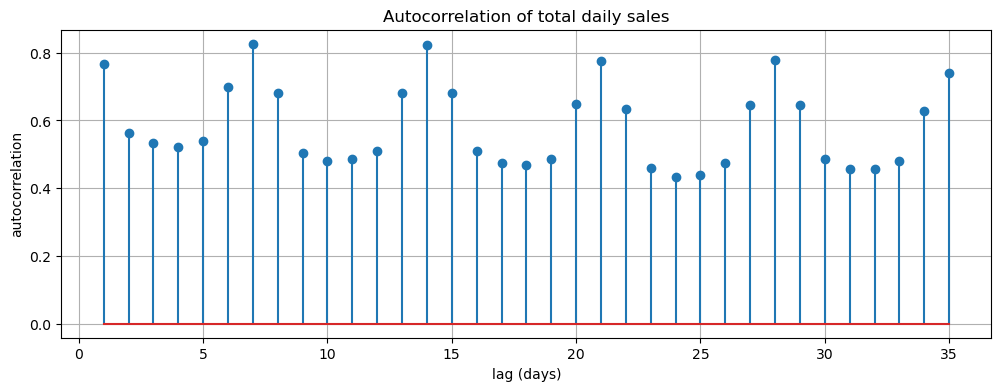

lag-1: 0.767   lag-7: 0.826   lag-14: 0.822   lag-365: 0.355


In [22]:
lags = range(1, 36)
ac = [daily['sales'].autocorr(l) for l in lags]

fig, ax = plt.subplots(figsize=(12, 4))
ax.stem(list(lags), ac)
ax.set_title('Autocorrelation of total daily sales')
ax.set_xlabel('lag (days)')
ax.set_ylabel('autocorrelation')
plt.show()
print(f'lag-1: {ac[0]:.3f}   lag-7: {ac[6]:.3f}   lag-14: {ac[13]:.3f}   lag-365: {daily["sales"].autocorr(365):.3f}')

**Takeaway:** autocorrelation peaks at multiples of 7 (lag-7 r = **0.83** > lag-1 r = 0.77; lag-365 r = 0.36) — the weekly cycle dominates the series' memory, so lag-7/14/28 features and day-of-week interactions should carry most of the short-term signal.

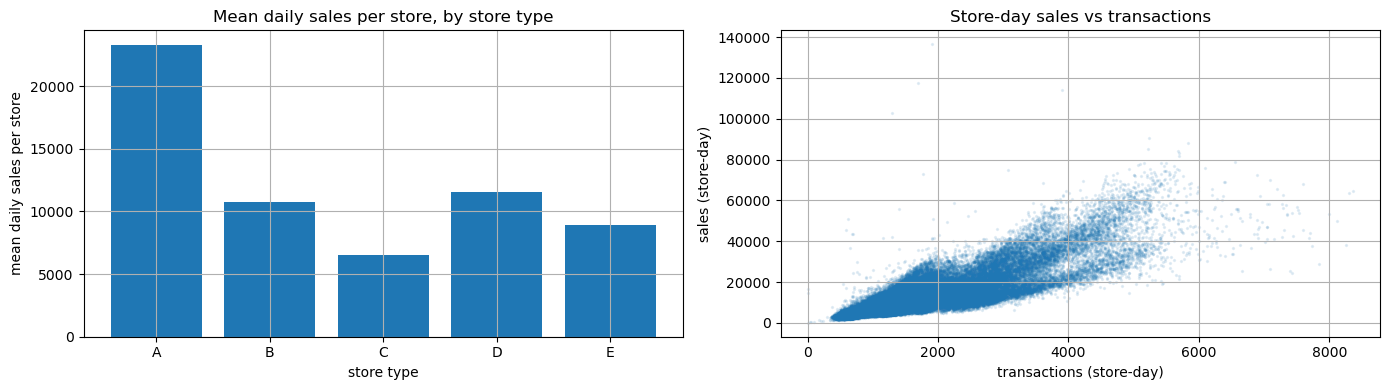

In [23]:
per_store_type = (train.merge(stores[['store_nbr', 'type']], on='store_nbr')
                  .groupby(['type', 'store_nbr', 'date'])['sales'].sum()
                  .groupby('type').mean())

st_daily = train.groupby(['date', 'store_nbr'])['sales'].sum().rename('sales').reset_index()
st_daily = st_daily.merge(transactions, on=['date', 'store_nbr'])

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(per_store_type.index, per_store_type.values)
axes[0].set_title('Mean daily sales per store, by store type')
axes[0].set_xlabel('store type')
axes[0].set_ylabel('mean daily sales per store')

axes[1].scatter(st_daily['transactions'], st_daily['sales'], s=2, alpha=0.1)
axes[1].set_title('Store-day sales vs transactions')
axes[1].set_xlabel('transactions (store-day)')
axes[1].set_ylabel('sales (store-day)')

plt.tight_layout()
plt.show()

**Takeaway:** type-A stores sell ≈ 23 K/day per store — roughly **2× type B/D and 3.5× type C** — so store type/cluster are strong level predictors; store-day transactions track sales closely, but since `transactions` ends with the train period it can only enter the model as **lagged/historical features**, never as a same-day input.

## 7. Key Findings Summary

1. **Structure:** train is a complete 1,684 × 54 × 33 panel (3,000,888 rows); only Dec 25 (×4) is absent. Test is the same grid for 16 future days.
2. **Target:** heavily right-skewed (skew 7.4, median 11, max 124.7 K) with **31.3 % exact zeros**; `log1p` normalises it (skew 0.41) → log-scale modelling / RMSLE.
3. **Trend & seasonality:** clear upward trend; weekly cycle is the strongest signal (lag-7 autocorr 0.83; Sunday +63 % vs Thursday); December peaks; Jan 1 ≈ closed.
4. **Events:** national holidays +19.5 % sales, payday window ≈ +7 %, and the 2016-04-16 earthquake lifted the following month +17.9 % — all extreme days are explainable, none are data errors.
5. **Heterogeneity:** family totals span ~5 orders of magnitude; BOOKS/BABY CARE are >94 % zeros (intermittent demand); type-A stores sell ~2–3.5× more per store than other types.
6. **Missingness is structural, not random:** only `oil.dcoilwtico` has NaNs (3.5 %, weekends/market holidays); 7 stores open mid-period (leading zeros = not open); `transactions` has **zero test coverage**.
7. **Covariates:** `onpromotion` starts 2014-04 and is more prevalent in the test window (44 % non-zero vs 20 % in train); the oil–sales correlation (−0.63) is **pure co-trend** (0.04 after detrending).
8. **Multicollinearity:** trend, oil and promotion volume are mutually correlated (|r| ≈ 0.6 in levels) — a trap for linear models, mostly harmless for trees.

## 8. Recommended Next Steps

### Preprocessing plan

| issue (finding) | treatment |
|---|---|
| Skew 7.4, 31 % zeros (§2) | model `log1p(sales)`; predict ≥ 0 via `expm1` + clip at 0 |
| 4 Dec-25 dates absent from train (§1) | **reinsert them with `sales = 0`** (stores closed, so zero is the true value) *before* building lag/rolling features — a row-based `groupby().shift()` otherwise silently misaligns every lag across the Christmas boundary; optionally drop them again for training |
| Oil NaNs are calendar-driven (§4) | reindex oil to the full daily calendar, forward-fill (then back-fill the first day); do **not** interpolate — interpolation peeks at future prices |
| Holiday table quirks: 38 duplicate dates, 12 transfers, Work Days, Bridge days (§5) | resolve transfers to actual celebrated dates; drop transferred-out rows; treat Work Day as *non*-holiday; de-duplicate per date; map Local/Regional to stores via `city`/`state`, National to all |
| Late-opening stores (§4) | **drop rows before each store's first sale** — simpler than a `days_since_open` feature and removes any risk of the model learning from fake zeros |
| Calendar effects (§6) | features: day-of-week, day-of-month, month, payday flags (15th/16th/17th, EOM, 1st/2nd), days-to/from national holiday, Dec-proximity |
| Earthquake (§2) | flag it from the **"Terremoto Manabi" Event rows already in `holidays_events.csv`** (they run from 2016-04-16 for weeks afterwards) — self-documenting and falls out of the holiday parsing for free, no manual Apr–May 2016 dummy needed |
| Per-series scale differences (§5) | per-(store, family) lag features: lag 16/21/28 (direct) or lag 1/7/14 (recursive), rolling means/std over 7/28 days; `transactions` only as lagged features (zero test coverage) |
| Dead series: pairs with all-zero recent history (§5) | **hard rule: predict 0** for any (store, family) whose last ~90+ days are all zero — nearly free RMSLE and keeps the global model from being pulled toward zero on series that do sell |
| Regime change: `onpromotion` starts 2014-04, 2013 trend/promo regime unlike 2017 (§3, §7) | experiment early with **truncating training history to 2015+** — the 16-day Aug-2017 horizon may be hurt more than helped by the oldest data |
| Categoricals ≤ 54 levels (§3) | native categorical dtype for gradient boosting; one-hot only if a linear model is used; no scaling needed for trees |
| Outliers (§5) | keep — they are real demand explained by calendar/events |
| Multicollinearity trend/oil/promo (§6) | irrelevant for trees; for linear models detrend first and use oil changes, not levels; per §6 the detrended oil signal is ≈ 0, so don't spend much effort on oil |

### Modelling strategy

- **Metric: RMSLE** (the competition metric) — equivalent to RMSE on the `log1p` target, which §2 showed is the natural scale.
- **Validation: strictly time-based.** Primary holdout = last 16 days of train (2017-07-31 → 2017-08-15), mirroring the test horizon; confirm with 3 rolling-origin folds (e.g. ending Jun 30, Jul 15, Jul 31). Never shuffle rows — the panel leaks badly under random CV.
- **Baselines first:** (1) naive "same day last week" per series, (2) 7-day / same-weekday rolling mean, (3) the all-zero rule for dead series from the table above. Cheap, and the lag-7 autocorrelation of 0.83 says they will already be respectable yardsticks.
- **Main candidate: a single global gradient-boosted tree model (LightGBM)** over all (store, family) series with the features above — chosen because the data are tabular with strong categorical structure (§3), zero-inflated and non-Gaussian (§2), nonlinear event effects (§6), and trees ignore the multicollinearity issue (§8 table). One model per forecast day ("direct" strategy, 16 models) avoids recursive error accumulation; recursive single-model is the fallback.
- **Worth trying after:** the classic hybrid for this competition — a linear/Fourier model for trend + weekly/yearly seasonality, with a GBDT on the residuals; and more refined intermittent-demand handling (beyond the all-zero rule) for the >94 %-zero families like BOOKS and BABY CARE.
- **Not yet:** no model is trained in this notebook — next notebook starts with the baselines and the validation split defined here.